# Does SAE reconstruction preserve model behavior?

Vector reconstruction error and prediction damage answer different questions. These are sampled fidelity checks, not reading-time effects. Provo’s two boundary policies coincide and appear once.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.report_bundle import read_summary, verify_bundle
from src.utils import focus_table, display_details
REPORTS = Path(os.environ.get("SAERT_REPORTS_DIR", ROOT/"reports"))
verify_bundle(REPORTS)
def load(section, name): return read_summary(section, name, REPORTS)
def figure(section, name): display(Image(filename=str(REPORTS/section/(name+".png"))))


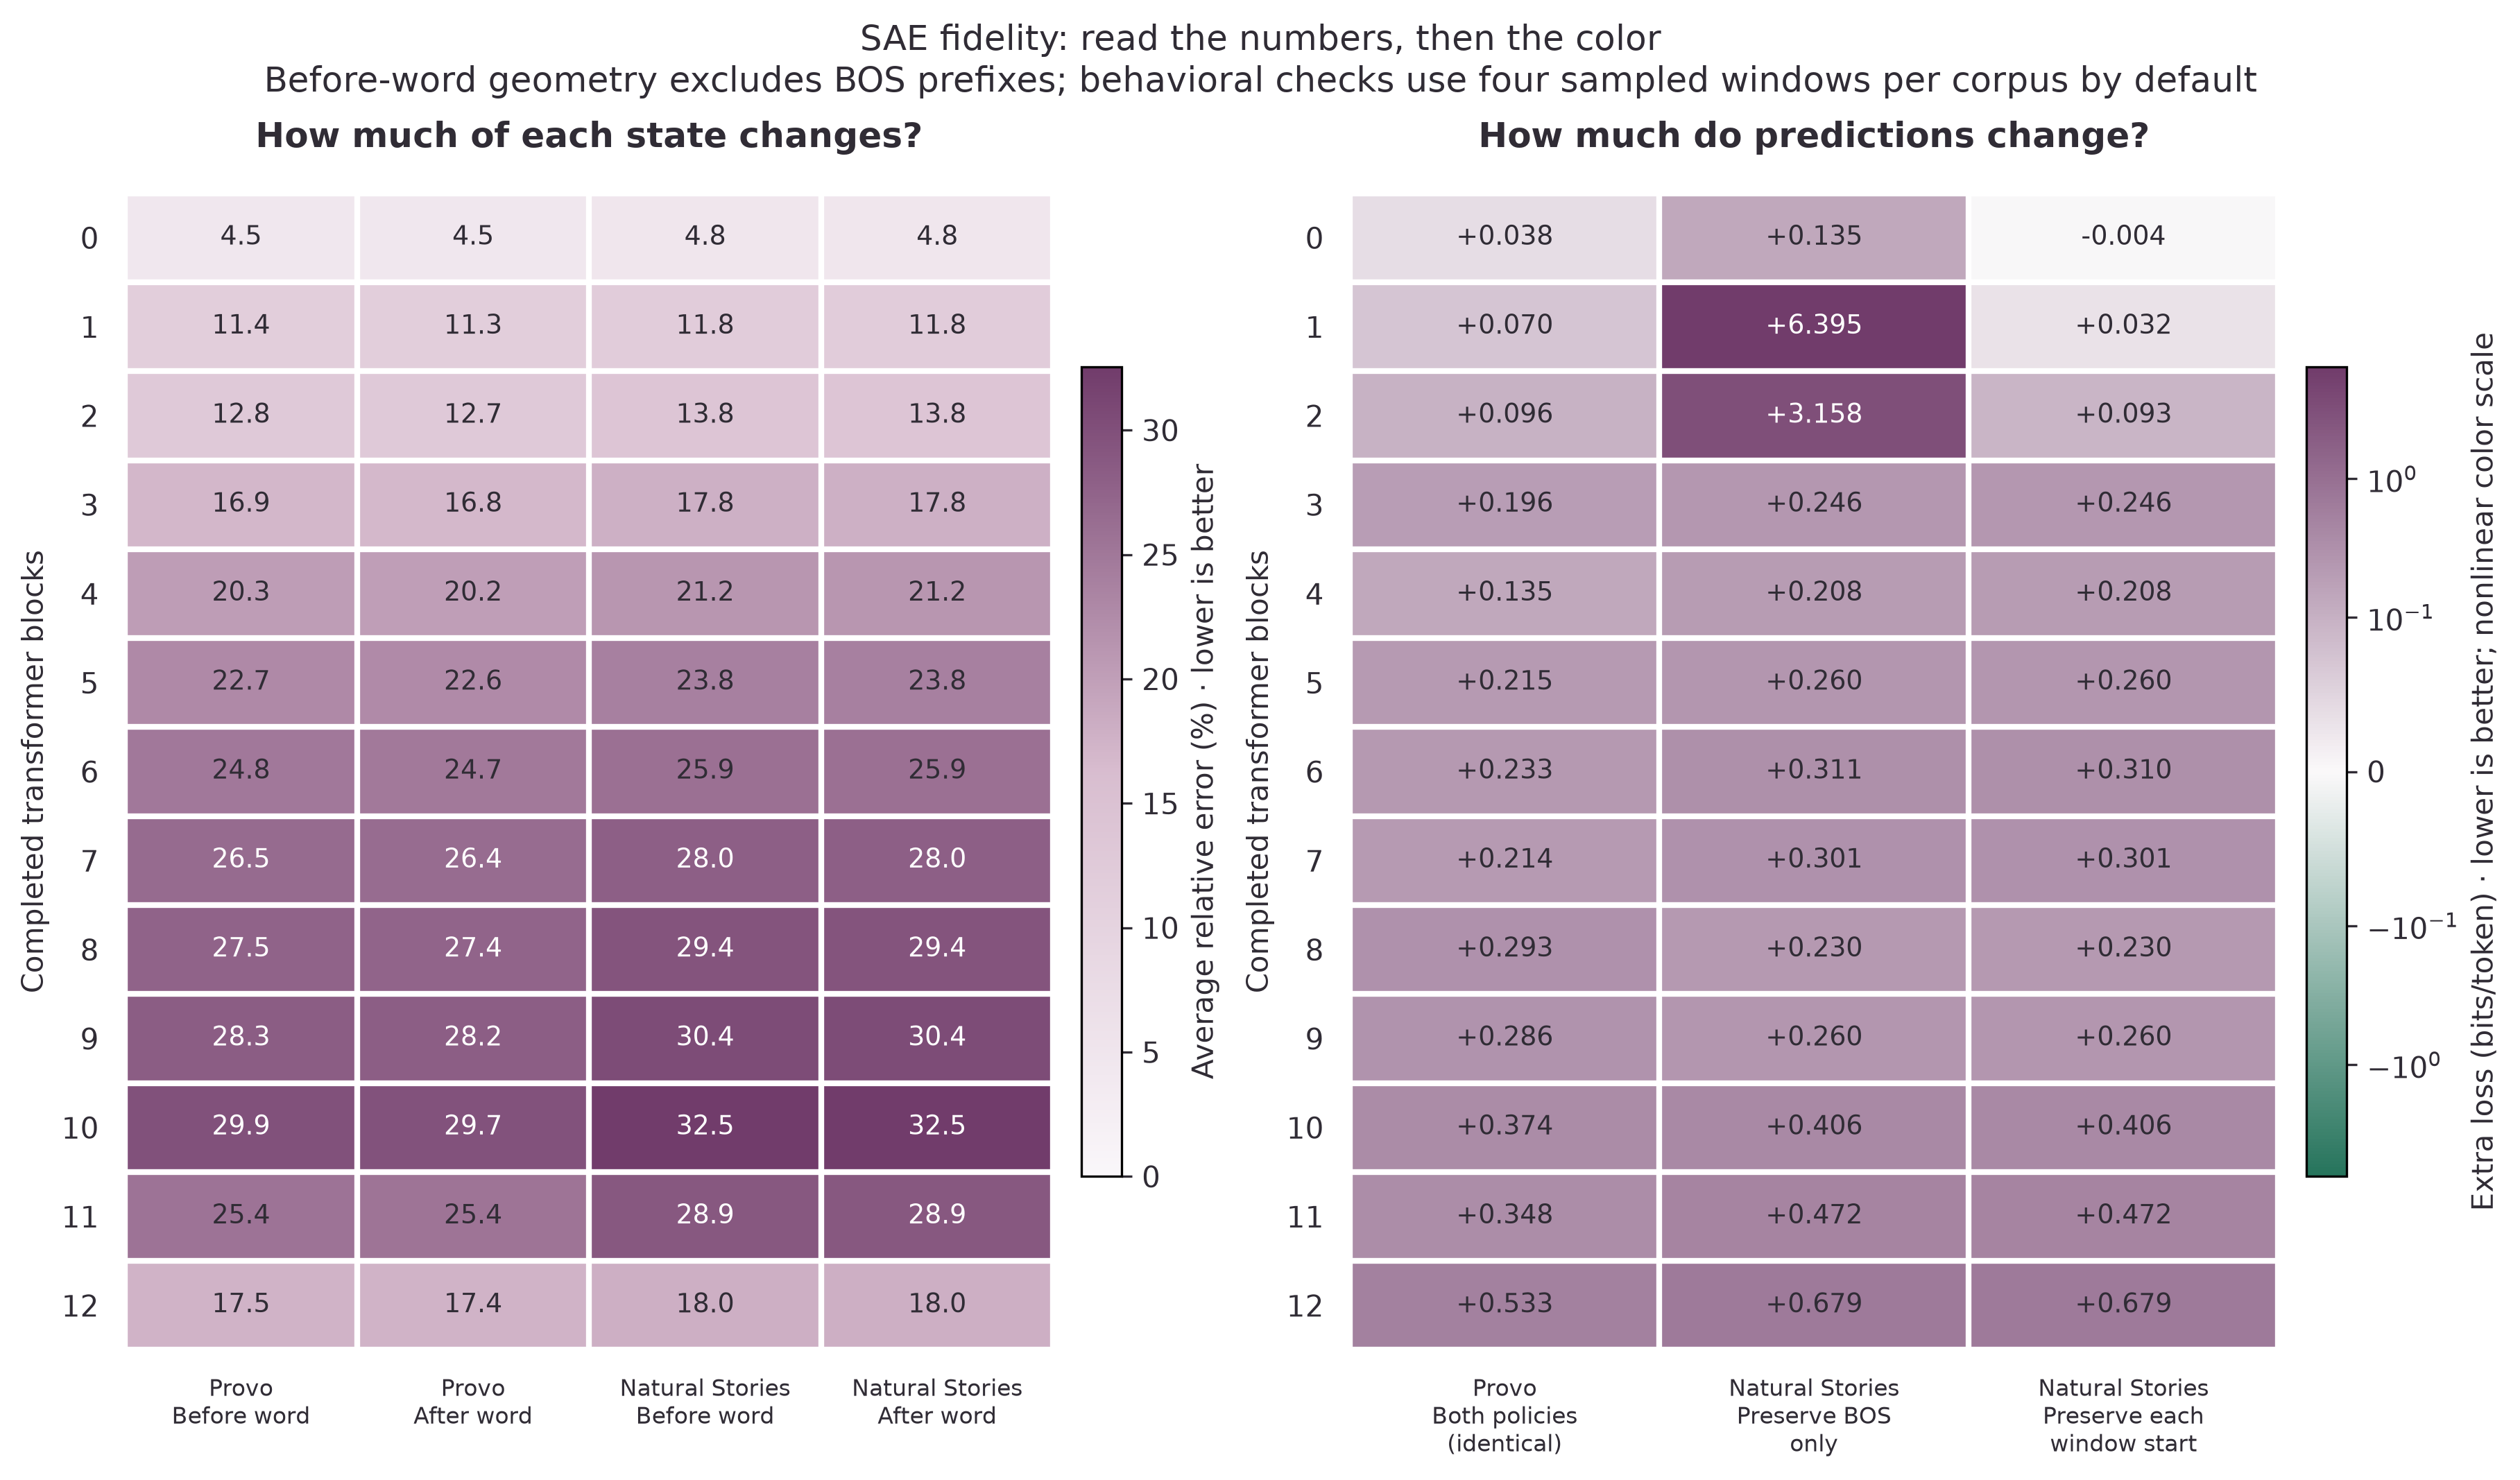

In [2]:
figure("sae_fidelity","sae_fidelity")

Rows count completed transformer blocks: 0 = L01, 1 = L02, and 12 = final residual. Left: relative vector error (%). Right: added NLL (bits/token). The nonlinear color scale preserves visibility across magnitudes; printed numbers remain untransformed. Preserving window starts does not validate the excluded states. Expand this four-window sample before interventions.

In [3]:
display_details("Behavioral fidelity",load("sae_fidelity","behavior_summary"))
display_details("Geometric fidelity",load("sae_fidelity","geometry_summary"))

corpus,label,hook,policy,n_windows,n_scored_tokens,original_nll_bits,reconstruction_nll_bits,zero_nll_bits,nll_increase_bits,kl_bits,loss_recovered,identity_kl_bits
provo,L01,blocks.0.hook_resid_pre,protect_bos,4,236,5.624,5.662,18.112,0.038,0.028,0.997,0.000
provo,L01,blocks.0.hook_resid_pre,protect_window_start,4,236,5.624,5.662,18.112,0.038,0.028,0.997,0.000
provo,L02,blocks.1.hook_resid_pre,protect_bos,4,236,5.624,5.694,11.232,0.070,0.038,0.988,0.000
provo,L02,blocks.1.hook_resid_pre,protect_window_start,4,236,5.624,5.694,11.232,0.070,0.038,0.988,0.000
provo,L03,blocks.2.hook_resid_pre,protect_bos,4,236,5.624,5.721,11.805,0.096,0.089,0.984,0.000
provo,L03,blocks.2.hook_resid_pre,protect_window_start,4,236,5.624,5.721,11.805,0.096,0.089,0.984,0.000
provo,L04,blocks.3.hook_resid_pre,protect_bos,4,236,5.624,5.820,18.300,0.196,0.159,0.985,0.000
provo,L04,blocks.3.hook_resid_pre,protect_window_start,4,236,5.624,5.820,18.300,0.196,0.159,0.985,0.000
provo,L05,blocks.4.hook_resid_pre,protect_bos,4,236,5.624,5.759,17.216,0.135,0.142,0.988,0.000
provo,L05,blocks.4.hook_resid_pre,protect_window_start,4,236,5.624,5.759,17.216,0.135,0.142,0.988,0.000


corpus,hook,label,kind,group,n_rows,mean_active,fraction_zero_rows,mean_relative_l2_error,mean_cosine_similarity,reconstruction_r2_centered
provo,blocks.0.hook_resid_pre,L01,post,all,2743,12.614,0.000,0.045,0.997,0.981
provo,blocks.0.hook_resid_pre,L01,prefix,all,2743,12.644,0.000,0.044,0.997,0.983
provo,blocks.0.hook_resid_pre,L01,prefix,text_token,2688,12.780,0.000,0.045,0.997,0.980
provo,blocks.0.hook_resid_pre,L01,prefix,bos,55,6.000,0.000,0.003,1.000,NaN
provo,blocks.1.hook_resid_pre,L02,post,all,2743,14.093,0.000,0.113,0.993,0.946
provo,blocks.1.hook_resid_pre,L02,prefix,all,2743,14.016,0.000,0.112,0.993,0.966
provo,blocks.1.hook_resid_pre,L02,prefix,text_token,2688,14.200,0.000,0.114,0.993,0.946
provo,blocks.1.hook_resid_pre,L02,prefix,bos,55,5.000,0.000,0.004,1.000,NaN
provo,blocks.2.hook_resid_pre,L03,post,all,2743,18.658,0.000,0.127,0.991,0.941
provo,blocks.2.hook_resid_pre,L03,prefix,all,2743,18.616,0.000,0.126,0.991,0.993
